# Final Project: Demographic Predictors of Wine Spending

**Group Members:** Maksim Strelkov, Darshit Sapkota , Hrishil Patel, Shayan Dhillon


**Date**: 02/04/2026

---

## Research Question

**Which customer demographics and behaviors best predict wine spending?**

## ***Summary***

Investigate:

1. How much children & teens in home affects time since purchase & amount spent

2. Are people of a certain marital status more likely to spend more and often?
    
3. What income group is more likely to spend on wine?

4. Can customers be segmented into distinct groups based on demographics and purchasing behavior using clustering techniques?

5. Can machine learning models (regression and classification) accurately predict wine spending based on customer demographics and behaviors?

**Data Source:** [Customer Personality Analysis](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)

---

# 0. GitHub Repository link

The IPYNB was hosted publically on GitHub with a commit history of everyones contributions here: [Repository](https://github.com/ShayanDhillon/Data200-Final-Customers)



---

# 1. Setup & Data Loading

In [71]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_keep = ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines']

df = pd.read_csv("marketing_campaign.csv", sep="\t")
df = df[columns_to_keep]
print("Data shape:", df.shape)


Data shape: (2240, 10)


The dataset has ten columns across thousands of varying customers

Customers

    - ID:             Customer's unique identifier
    - Year_Birth:     Customer's birth year
    - Education:      Customer's education level
    - Marital_Status: Customer's marital status
    - Income:         Customer's yearly household income
    - Kidhome:        Number of children in customer's household
    - Teenhome:       Number of teenagers in customer's household
    - Dt_Customer:    Date of customer's enrollment with the company
    - Recency:        Number of days since customer's last purchase
    - Complain:       1 if the customer complained in the last 2 years, 0 otherwise

Target

    - MntWines:       Amount spent on wine in last 2 years

---

# 2. Data Cleaning

In [72]:
# normal data cleaning and formatting stuff
# finding missing values, duplicates, outliers, etc. and fixing them

# missing values
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0], end="\n\n")

# duplicates
print("Duplicate rows:", df.duplicated().sum(), end="\n\n")

#remove missing values
df = df.dropna()
print("Data shape after dropping missing values:", df.shape, end="\n\n")

Missing values:
Income    24
dtype: int64

Duplicate rows: 0

Data shape after dropping missing values: (2216, 10)



In [73]:
# make objects into categories

print("Non standard data types:")
print(df.select_dtypes(include=['object']).dtypes)

# convert Marital_Status to category
df['Marital_Status'] = df['Marital_Status'].astype('category')

#convert education to ordinal category
edu_order = ['Basic', 'Graduation', '2n Cycle', 'Master', 'PhD']
df['Education'] = pd.Categorical(df['Education'], categories=edu_order, ordered=True)

# convert Dt_Customer to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

df.head(5)

Non standard data types:
Education         object
Marital_Status    object
Dt_Customer       object
dtype: object


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173


In [74]:
# clean up some categories, what do they really mean?


# make new marital status, changes to single or partnered
def simplify_marital_status(status):
    if status in ['Married', 'Together']:
        return 'Partnered'
    elif status in ['Single', 'Divorced', 'Widow', 'Alone']:
        return 'Single'
    else:
        return 'Other'

df['Marital_Simplified'] = df['Marital_Status'].apply(simplify_marital_status)
df['Marital_Simplified'] = df['Marital_Simplified'].astype('category')
#remove all "others"
df = df[df['Marital_Simplified'] != 'Other'] #removes "absurd" and "yolo" categories


After data cleaning, we are left with the data shape: (2212, 11), and the dataset is now ready for further feature engineering and exploration/analysis!

We made sure all columns are the correct data types (with proper ordering for ordinal variables).

---

# 3. Feature Engineering & Exploration

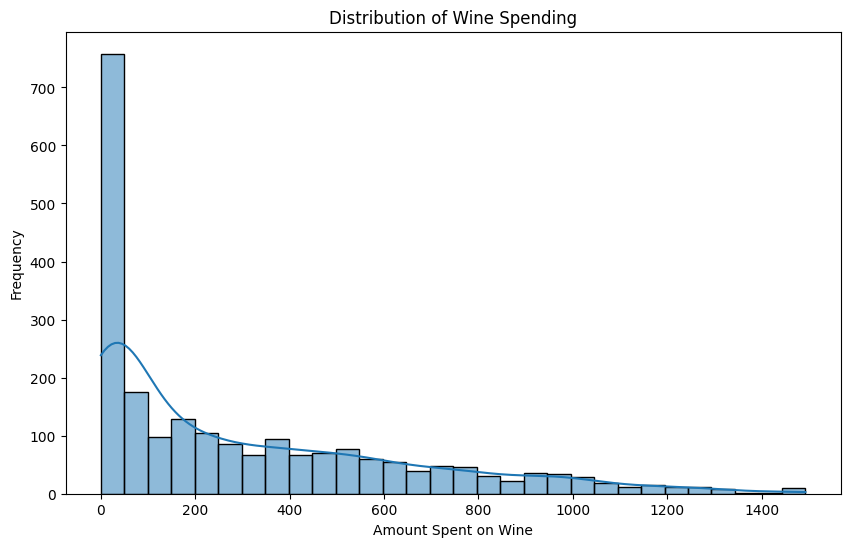

In [76]:
# distribution of wine spending to start off
plt.figure(figsize=(10, 6))
sns.histplot(df['MntWines'], bins=30, kde=True)
plt.title('Distribution of Wine Spending')
plt.xlabel('Amount Spent on Wine')
plt.ylabel('Frequency')
plt.show()



#did this one for u since its not part of the 3 :)

**Interpretation:**

The distribution of wine spending is very right-skewed, most customers spend low amounts on wine, only very few customers are high spenders. As shown by the long tail which extends to large spending amounts, there exists a premium segment of customers that drives a large portion of revenue from wine sales!

Finding commonalities among high spenders will be important for understanding the factors that drive increased spending on wine.


In [ ]:
# do feature engineering

# family types: "No Kids", "Young Kids", "Teenagers", "Mixed Kids"
# Make income groups (high med low whatever)


3.1 How much children & teens in home affects time since purchase & amount spent
    (children, teen and both, make new feature on family type)

**Interpretation:**


3.2 Are people of a certain marital status more likely to spend more and often?

**Interpretation:**


3.3 What income group is more likely to spend on wine?

**Interpretation:**




---

# 4. Modelling

## USE Regularization techniques, with appropriate interpretations (especially regarding the bias-variance tradeoff)

Setup

In [ ]:
#  cross validation, test train set etc

4.1 Clustering

In [ ]:
#CLUSTERING FIRST, make clusters as a feature and use in model

**Interpretation:**

4.2 Model Building

In [ ]:
#Regression and Classification

In [ ]:
# convergence plot

**Interpretation:**

In [ ]:
# final results plot

**Interpretation:**

---


# 5. Conclusion


Final conclusion